### intro

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

In [11]:
from langchain_groq import ChatGroq

# Faster and cheaper option than the 70B model
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0,
    max_tokens=200,
)


In [12]:
llm.invoke("Hi") 

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.027558749, 'completion_tokens_details': None, 'prompt_time': 0.001694237, 'prompt_tokens_details': None, 'queue_time': 0.052864103, 'total_time': 0.029252986}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb886-67ba-7b51-a4e9-19b2e43f3212-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [13]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0,
    max_tokens=200,
)

In [14]:
llm.invoke("Hi")

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.027152459, 'completion_tokens_details': None, 'prompt_time': 0.001618917, 'prompt_tokens_details': None, 'queue_time': 0.159733881, 'total_time': 0.028771376}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb887-e616-7042-9d56-98b5c2b0ea28-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [2]:
from langchain_community.llms.ollama import Ollama

llm = Ollama(model="qwen2:7b")

result = llm.invoke("Hello, how can I help you today?")
print(result)

Hello! As an AI language model, I don't have personal needs or desires. However, my purpose is to assist and provide information to users like you. How may I help you today? Do you have any specific questions or topics you would like to discuss or learn about?


In [6]:
from langchain_openai import ChatOpenAI

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Initialize ChatOpenAI pointing to your local Ollama server
llm = ChatOpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",  # Required by the SDK, ignored by Ollama
    model="qwen2:7b",  # Replace with the model you have pulled locally
    temperature=0.7
)

# Standard LangChain setup
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an AI assistant tasked with explaining things simply."),
    ("human", "{question}")
])

chain = prompt | llm | StrOutputParser()

# Execute the chain
response = chain.invoke({"question": "Why is the sky blue?"})
print(response)

The sky appears blue because of a phenomenon called Rayleigh scattering. When sunlight reaches Earth, it encounters molecules and small particles in our atmosphere. Sunlight is made up of many colors, each with a different wavelength (length of the wave). Blue light waves are shorter than red light waves.

As sunlight enters the Earth's atmosphere, the gas molecules like nitrogen and oxygen scatter the blue light more efficiently than other colors because their atoms interact better with the shorter blue wavelengths. This means that when you look up at the sky on a clear day, your eyes see all this scattered blue light coming from various directions above you.

When the sun is low in the sky near sunrise or sunset, the sunlight has to travel through more of the Earth's atmosphere to reach your eye. As it does this, much of the blue light gets scattered away by that time as well, so what you see instead is a combination of the remaining red and orange light from the sun, which creates t

In [3]:
from langchain.agents import create_agent

In [13]:
def get_weather(city: str) -> str:
    # Placeholder for actual weather fetching logic
    """ This function simulates fetching weather information for a given city. In a real-world scenario, you would replace this with an API call to a weather service. """
    return f"The weather in {city} is sunny."

In [14]:
agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a data scientist and a python programmer. You are given a task to write a python code to solve a problem. You will be given a problem statement and you have to write the code to solve the problem. You will also be given some test cases to test your code. You have to write the code in such a way that it passes all the test cases. You can use any python libraries to solve the problem. You have to write the code in a function named 'solve' which takes input from standard input (stdin) and prints the desired outputs to standard output (stdout)."
)

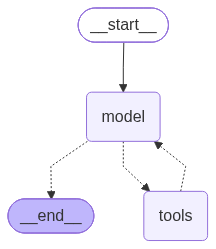

In [15]:
agent

In [17]:
agent.invoke({"message":[{"role": "user", "content": "Write a python code to find the sum of two numbers. The input will be two integers separated by a space. The output should be the sum of the two integers."}]})

{'messages': [AIMessage(content="To provide an effective solution, I need the problem statement you want me to solve. Kindly include the details of the problem and any specific requirements or constraints associated with it. Additionally, please provide some test cases if they are available for verification purposes. Once provided, I will write a Python function named 'solve' to address this issue using appropriate libraries while ensuring that the code meets all specified criteria.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 270, 'total_tokens': 351, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2:7b', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-259', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fc37d-9444-79e1-9907-3340dfa76a6f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 270, 'output_tokens': 81,

In [18]:
inputs = {
    "messages": [
        {
            "role": "user", 
            "content": "Write a python code to find the sum of two numbers. The input will be two integers separated by a space. The output should be the sum of the two integers."
        }
    ]
}

# 2. Iterate through the stream using "messages" mode
for chunk in agent.stream(inputs, stream_mode="messages", version="v2"):
    if chunk["type"] == "messages":
        # Extract the message chunk and its metadata
        message_chunk, metadata = chunk["data"]
        
        # Verify the content exists and print it token-by-token
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)

```python
def solve(num1, num2):
    """
    This function takes two integers as input and returns their sum.
    
    Parameters:
    num1 (int): First integer.
    num2 (int): Second integer.
    
    Returns:
    int: The sum of num1 and num2.
    """
    return num1 + num2

if __name__ == "__main__":
    # Reading input from stdin
    line = input().strip()
    # Splitting the input string into two parts based on space, converting each part to an integer
    num1, num2 = map(int, line.split())
    # Calculating the sum using the solve function
    result = solve(num1, num2)
    # Printing the result to stdout
    print(result)
```

In [19]:
inputs = {
    "messages": [
        {
            "role": "user", 
            "content": "Wether oof bangalore city"
        }
    ]
}

# 2. Iterate through the stream using "messages" mode
for chunk in agent.stream(inputs, stream_mode="messages", version="v2"):
    if chunk["type"] == "messages":
        # Extract the message chunk and its metadata
        message_chunk, metadata = chunk["data"]
        
        # Verify the content exists and print it token-by-token
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)

The weather in Bangalore is sunny.The weather in Bangalore is sunny.

In [29]:
response = agent.invoke(inputs)

In [26]:
response

{'messages': [HumanMessage(content='Wether oof bangalore city', additional_kwargs={}, response_metadata={}, id='1b1a7684-1e45-4651-aeb6-2a2f3df102db'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 282, 'total_tokens': 308, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2:7b', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-995', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fc609-d241-7220-b860-d9e0529c090e-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Bangalore'}, 'id': 'call_dmk6ocxe', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 282, 'output_tokens': 26, 'total_tokens': 308, 'input_token_details': {}, 'output_token_details': {}}),
  ToolMessage(content='The weather in Bangalore is sunny.', name='get_weather', id='2d0e1aff-4a1d-4b9c-ba7a-1d15bfc6d9d8', tool_cal

In [27]:
response["messages"][-1].content

'The weather in Bangalore is sunny.'